# Regression Metrics

Follow _Introduction to Machine Learning_ [Chapter 5](https://github.com/amueller/introduction_to_ml_with_python/blob/master/05-model-evaluation-and-improvement.ipynb) **Section 5.3.4 Regression Metrics** (p.306)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import mglearn

## Regression metrics

R-squared `sklearn.metrics.r2_score`
>It represents the proportion of variance (of y) that has been explained by the independent variables in the model. It provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model, through the proportion of explained variance.

see [Coefficient of determination](https://en.wikipedia.org/wiki/Coefficient_of_determination) for more information.

$\frac{\sum(y - \bar{y})^2 - \sum(y - \hat{y})^2}{\sum(y - \bar{y})^2} = 1 -  \frac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$

Mean-squared error `sklearn.metrics.mean_squared_error`

$\frac{1}{N} \sum (y - \hat{y})^2$

Root mean-squared error `sklearn.metrics.mean_squared_error(squared=False)`

$\sqrt{\frac{1}{N} \sum (y - \hat{y})^2}$

Mean absolute error `sklearn.metrics.mean_absolute_error`


$\frac{1}{N} \sum |y - \hat{y}|$

In [13]:
y = 10*np.random.rand(50)+2
y

array([ 5.45804645,  6.95964308, 10.46830831,  8.52006049,  4.03464337,
        5.04757984,  5.24998817,  8.29025932,  5.33138064,  7.85117983,
        3.00607002,  3.72500228,  7.09612779,  5.696257  ,  7.50939109,
        3.99763309,  3.11394566,  6.69282218,  4.4126813 ,  5.58670194,
        5.10195332,  9.31033192, 10.67613929, 10.00376561,  5.99699713,
       11.14507101, 10.02676545,  6.95374488,  9.48563442,  5.55753571,
        9.80956158,  7.14584906, 11.28253923,  7.41800893,  7.09534767,
        4.76753   ,  3.90990347,  9.3477651 ,  9.33134211,  9.02152996,
        3.10669493, 11.94503425,  2.88769023,  2.92107795,  6.2853806 ,
        2.9739707 , 11.33510653,  7.65695737,  7.42330987,  5.19569879])

In [14]:
y_pred = y + 2*np.random.rand(50)
y_pred[-1] = 1.6 * y[-1] #a slight outlier
y_pred

array([ 7.16767032,  7.93339633, 10.69104307,  9.79459999,  4.3778826 ,
        6.47772386,  5.88669726,  8.8339723 ,  6.62473036,  9.58155707,
        3.24282793,  4.7563865 ,  7.63043918,  7.477248  ,  7.52212013,
        4.96355705,  4.2920066 ,  7.92880616,  5.93940852,  7.54317089,
        5.25993284, 10.73447465, 11.80268077, 11.83184724,  7.28268959,
       11.96216698, 10.57159812,  7.63743651, 11.19272041,  6.3399853 ,
       11.52666923,  8.92116122, 12.39056922,  8.12770649,  8.62937397,
        5.70599485,  4.73957215, 10.54804162,  9.87117692,  9.24021464,
        4.82348145, 13.8905926 ,  2.9378121 ,  3.51322821,  7.37110102,
        3.26135875, 12.37443919,  8.53609334,  7.56250157,  8.31311806])

### Predicted vs actual plot

Combined with a line of unity to assess biases in predictons.

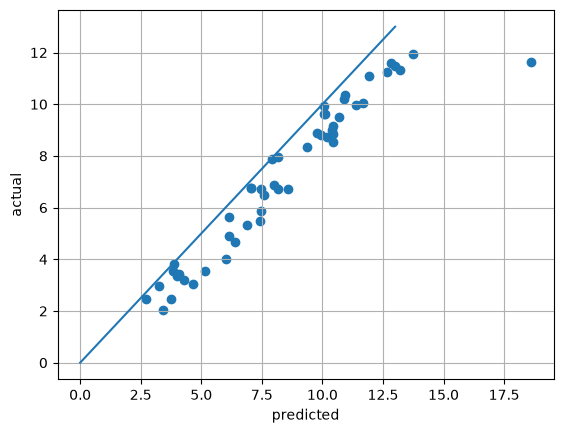

In [5]:
plt.scatter(y_pred, y)
plt.plot([0, 13], [0, 13])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.grid(True)

### Residual plot

Assess distribution of errors and dependency on magnitude of predicted value.

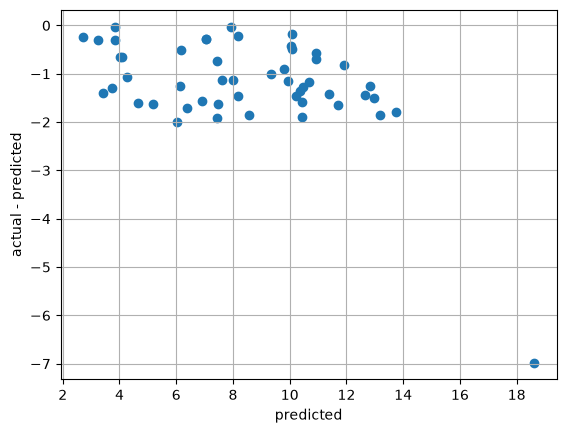

In [6]:
plt.scatter(y_pred, y-y_pred)
plt.xlabel('predicted')
plt.ylabel('actual - predicted')
plt.grid(True)

In [15]:
# Calculate R2 manually
1 - sum((y-y_pred)**2)/sum((y-y.mean())**2)

np.float64(0.7770917395802766)

In [16]:
from sklearn.metrics import r2_score
r2_score(y, y_pred)

0.7770917395802763

In [17]:
# Calculate mse manually
sum((y-y_pred)**2) / len(y)

np.float64(1.4881560488995393)

In [18]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import root_mean_squared_error as rmse
mse(y, y_pred)

1.4881560488995398

In [19]:
# Calculate rms manually
np.sqrt(sum((y-y_pred)**2) / len(y))

np.float64(1.219900015943741)

In [20]:
rmse(y, y_pred)

1.2199000159437412

In [13]:
# Calculate mae manually
sum(np.abs(y-y_pred)) / len(y)

1.1036060989208338

In [14]:
from sklearn.metrics import mean_absolute_error as mae
mae(y, y_pred)

1.1036060989208338

## Negative $R^2$?

In [15]:
x = np.linspace(0, 10, 50)
x

array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])

In [16]:
np.random.seed(345)
y = -0.1*x**2+np.random.randn(50)+8
y

array([ 9.46924823,  6.84569076, 10.50256581,  7.88003797,  7.8997602 ,
        6.25922111,  7.43796999,  9.58086739,  7.77582735,  7.04290855,
        6.59181629,  7.63251063,  8.05693087,  6.79971652,  6.951097  ,
        7.4427832 ,  7.46915178,  5.60221996,  5.13612727,  6.61246535,
        6.59305291,  7.2294732 ,  5.54417131,  3.64972928,  4.88234632,
        4.94052172,  4.06125135,  4.32530868,  4.32878758,  4.89270049,
        3.71259272,  3.38735709,  4.12353015,  3.60141911,  3.04174249,
        3.07343655,  2.56404523,  3.52795518,  1.18175509,  1.22677715,
        1.70050085,  0.49168713, -1.27354158, -0.30594167, -1.64670799,
       -0.9954155 , -0.16744344, -0.87718239, -1.81255468, -2.80012579])

Text(0, 0.5, 'target')

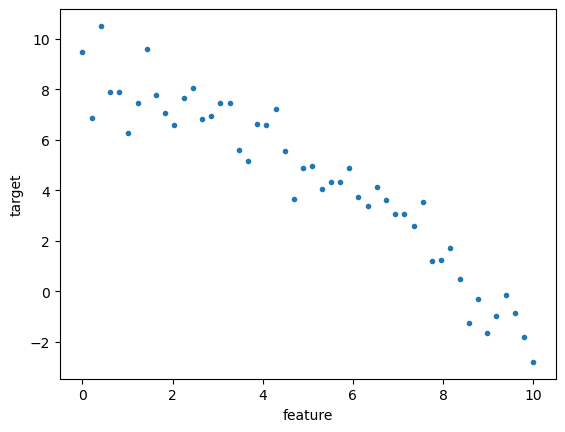

In [17]:
plt.plot(x, y, '.');
plt.xlabel('feature')
plt.ylabel('target')

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
model = LinearRegression(fit_intercept=False)
model.fit(x[:,None],y).score(x[:,None],y)

-1.338864672807301

Text(0, 0.5, 'target')

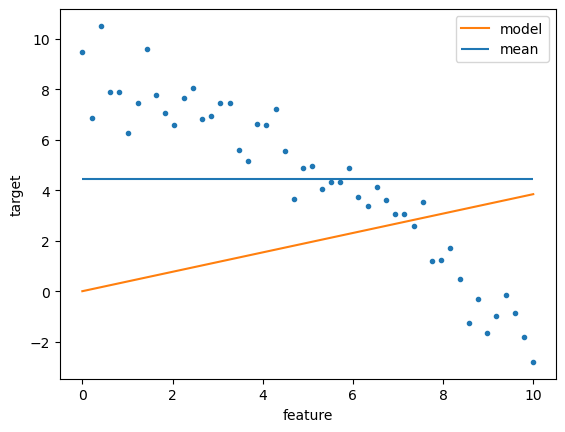

In [20]:
xline = np.linspace(0, 10, 20)
y_pred = model.predict(xline[:,None])

plt.plot(x, y, '.');
plt.plot(xline, y_pred, label='model');
plt.hlines(y=y.mean(), xmin=0, xmax=10, label='mean')
plt.legend()
plt.xlabel('feature')
plt.ylabel('target')

Why do we get a negative $R^2$?

It is possible to get a negative $R^2$ when the model performs worse than the constant-mean predictor

$R^2 = 1 -  \frac{\sum(y - \hat{y})^2}{\sum(y - \bar{y})^2}$

For a *bad* model, the numerator will be larger than the denominator, making the value negative.

For linear regression it can happen when no intercept is fitted.

See:

https://stackoverflow.com/questions/30507245/negative-r2-on-training-data-for-linear-regression

https://stats.stackexchange.com/questions/12900/when-is-r-squared-negative